## Implement a L-layer neural network
parameters: 
$$
W_1, b_1, W_2, b_2, ..., W_L, b_L
$$

hyperparameters: 
- learning rate
- number of iterations
- number of hidden layers (L)
- number of hidden units ($n_1, n_2, ..., n_L$)
- activation function in each layer

In [25]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
from dnn_app_utils_v3 import *
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

y = 0. It's a non-cat picture.


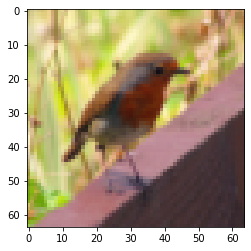

In [27]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()
# Example of a picture
index = 10
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [145]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [226]:
# Reshape the training and test examples 
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


In [270]:
def act_func(Z, func = "relu", grad=False):
    if func == "relu":
        if grad==False:
            return np.maximum(Z, 0)
        else:
            return np.where(Z <= 0, 0, 1)
    else:
        if grad==False:
            return 1/(1+np.exp(-Z))
        else: 
            s = 1/(1+np.exp(-Z))
            return s * (1-s)

### A function for 
- intializing parameters
- forward propagation
- backward propagation
- computing cost function
- updating parameters

In [245]:
def create_parameters(layer_dims): 
    params = {}
    L = len(layer_dims)
    print(layer_dims)
    for l in range(1, L):
        params["W"+str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(layer_dims[l-1])
        params["b"+str(l)] = np.zeros((layer_dims[l], 1))
        print("W", l, " shape: ", params["W"+str(l)].shape)
        print("b", l, " shape: ", params["b"+str(l)].shape)
        
    return params

In [247]:
def buggy_create_parameters(layer_dims):
    params = {}
    L = len(layer_dims)
    print(layer_dims)
    for l in range(1, L):
        params["W"+str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        params["b"+str(l)] = np.zeros((layer_dims[l], 1))
        print("W", l, " shape: ", params["W"+str(l)].shape)
        print("b", l, " shape: ", params["b"+str(l)].shape)
        
    return params

In [229]:
def forward(params, X, Y, layer_dims):
    linear_actvs = {}
    L = len(layer_dims)
    # X.shape should be (layer_dim[0], m)
    # m = #training examples
    linear_actvs["A0"] = X

    for l in range(1, L): 
        linear_actvs["Z"+str(l)] = np.dot(params["W"+str(l)], linear_actvs["A"+str(l-1)]) + params["b"+str(l)]
        if l!=L-1:
            linear_actvs["A"+str(l)] = act_func(linear_actvs["Z"+str(l)], func = "relu")
        else:
            linear_actvs["A"+str(l)] = act_func(linear_actvs["Z"+str(l)], func = "sigmoid")
    
    
    #print("AL in forwards", linear_actvs["A"+str(L-1)])
    

    return linear_actvs

In [230]:
def backward(params, layer_dims, Y, linear_actvs, m, loss_func="add later"):
    grads = {}
    L = len(layer_dims)-1
    
    grads["dA"+str(L)] = np.divide(-Y, linear_actvs["A"+str(L)]) + np.divide(1-Y, 1 - linear_actvs["A"+str(L)])
    grads["dZ"+str(L)] = np.multiply(grads["dA"+str(L)], act_func(linear_actvs["Z"+str(L)], func="sigmoid", grad=True))
    
    # from l = L to l = 1
    for l in range(L, 0, -1):
        grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
        grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
        if l!=1:
            grads["dA"+str(l-1)] = np.dot((params["W"+str(l)]).T, grads["dZ"+str(l)])
            grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], act_func(linear_actvs["Z"+str(l-1)], func="relu", grad=True))
    
    return grads

In [231]:
def compute_cost(layer_dims, Y, linear_actvs, m):
    L = len(layer_dims)
    AL = linear_actvs["A"+str(L-1)] # A2
    # print("AL in compute cost:", AL)
    cost = -1/m * (np.sum(np.multiply(Y, np.log(AL))) + np.sum(np.multiply((1-Y), np.log(1-AL))))
    cost = np.squeeze(cost)
    # print("asdasdasd", cost)
    return cost

In [232]:
def update_params(params, grads, layer_dims, lr):
    L = len(layer_dims)
    for l in range(1, L):
        params["W"+str(l)] = params["W"+str(l)] - lr * grads["dW"+str(l)]
        params["b"+str(l)] = params["b"+str(l)] - lr * grads["db"+str(l)]
    return params

### All in one function:
- initialize parameters
- compute loss using forward function (store A, Z when forwarding)
- by doing back propagation, compute gradients of parameters with respect to calculated loss (using A,Z stored in forward propagation and params)
- compute cost function
- update parameters according to gradients calculated in back propagation (gradien descent)
- repeat steps 2 to 5 for the number of iterations

In [274]:
def model(X, Y, layer_dims, num_iterations, lr):
    #np.random.seed(1)

    params = create_parameters(layer_dims)
    # params = buggy_create_parameters(layer_dims)
    
    m = X.shape[1] # ?
    print("m:", m)

    for i in range(num_iterations):
        linear_actvs = forward(params, X, Y, layer_dims)
        grads = backward(params, layer_dims, Y, linear_actvs, m)
        cost = compute_cost(layer_dims, Y, linear_actvs, m)
        params = update_params(params, grads, layer_dims, lr)
        if i % 100 == 0 or i == num_iterations-1:
           print("cost after iteration ", i, ": ", cost)
    return params

In [275]:
def predict(X, y, params):
    m = X.shape[1]
    n = len(params) // 2 # number of layers in the neural network
    p = np.zeros((1,m))
    # Forward propagation
    linear_actvs = forward(params, X, Y, layer_dims)
    yhat = linear_actvs["A"+str(n)]

    # convert yhat to 0/1 predictions
    for i in range(0, yhat.shape[1]):
        if yhat[0,i] > 0.5:
            p[0,i] = 1
        else:
            p[0,i] = 0
    
    #print results
    #print ("predictions: " + str(p))
    #print ("true labels: " + str(y))
    print("Accuracy: "  + str(np.sum((p == y)/m)))
    
    return p

In [276]:
layer_dims = [12288, 20, 7, 5, 1] #  4-layer model

In [280]:
deeper_params = model(train_x, train_y, layer_dims, 2500, 0.0075)

[12288, 20, 7, 5, 1]
W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (7, 20)
b 2  shape:  (7, 1)
W 3  shape:  (5, 7)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
m: 209
cost after iteration  0 :  0.6802432415740044
cost after iteration  100 :  0.5412880302013378
cost after iteration  200 :  0.46301169012063265
cost after iteration  300 :  0.425736896665087
cost after iteration  400 :  0.36083053584822705
cost after iteration  500 :  0.3319867313300074
cost after iteration  600 :  0.2781179254118663
cost after iteration  700 :  0.22331409131239896
cost after iteration  800 :  0.1640075828154169
cost after iteration  900 :  0.12062377349123032
cost after iteration  1000 :  0.08793863905540272
cost after iteration  1100 :  0.06924769336897944
cost after iteration  1200 :  0.040396081231423416
cost after iteration  1300 :  0.029669825672850193
cost after iteration  1400 :  0.023132380212886994
cost after iteration  1500 :  0.018689475753734388
cost after iteration

In [281]:
pred_train = predict(train_x, train_y, deeper_params)

Accuracy: 0.9999999999999998


In [282]:
pred_test = predict(test_x, test_y, deeper_params)

Accuracy: 0.74
